In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Change to your GPU

import torch
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of visible GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"Device {i}: {torch.cuda.get_device_name(i)}")

1
NVIDIA GeForce RTX 3090
CUDA available: True
Number of visible GPUs: 1
Device 0: NVIDIA GeForce RTX 3090


In [2]:
# ============================================================================
# IMPORTS
# ============================================================================

import cv2
import numpy as np
import random
import torch
import torch.nn as nn
import gc
import os
import pandas as pd
import hashlib
from tqdm import tqdm
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from PIL import Image
import json
import time
from datetime import datetime
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sklearn_auc, classification_report
import shutil

In [3]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# NIH-CXR14 paths
IMG_DIR = Path("/data0/NIH-CXR14/images")
RAW_CSV = Path("/data0/NIH-CXR14/Data_Entry_2017_v2020.csv")
WORK_DIR = Path("/home/jupyter-yin10/Image_Analysis")
OUTPUT_DIR = WORK_DIR / "NIH_Localized_Blur_Grid_8x8_ResNet50"

# Use same split as DINOv3/RAD-DINO 8×8
SPLIT_SOURCE = WORK_DIR / "NIH_Localized_Blur_8x8"
TRAIN_CSV = OUTPUT_DIR / "train.csv"
TEST_CSV = OUTPUT_DIR / "test.csv"

# Grid blur parameters (IDENTICAL to Emory)
GRID_SIZE = 8          # 8×8 grid of pixels (64 total pixels)
PIXEL_SPACING = 1      # 1 pixel between each grid point
BLUR_KSIZE = 21        # Gaussian kernel applied around each pixel (must be odd)
BLUR_SIGMA = 0         # Auto-selected by OpenCV

# Grid placement: centered with margin
PLACEMENT_MARGIN = 0.20  # 20% margin from edges

# ResNet-50 training (IDENTICAL to Emory)
TARGET_SIZE = (448, 448)  # Input size for ResNet-50
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-4

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
# ============================================================================
# COPY TRAIN/TEST SPLIT FROM DINOV3/RAD-DINO 8×8
# ============================================================================

source_train = SPLIT_SOURCE / "train.csv"
source_test = SPLIT_SOURCE / "test.csv"

if source_train.exists() and source_test.exists():
    print("Copying train/test split from DINOv3/RAD-DINO 8×8...")
    
    shutil.copy(source_train, TRAIN_CSV)
    print(f"✓ Copied: {source_train} → {TRAIN_CSV}")
    
    shutil.copy(source_test, TEST_CSV)
    print(f"✓ Copied: {source_test} → {TEST_CSV}")
    
    # Verify
    df_train = pd.read_csv(TRAIN_CSV)
    df_test = pd.read_csv(TEST_CSV)
    print(f"\nTrain set: {len(df_train)} images")
    print(f"Test set:  {len(df_test)} images")
    print("✅ Using IDENTICAL split as DINOv3/RAD-DINO 8×8!")
else:
    raise FileNotFoundError(
        f"Split files not found in {SPLIT_SOURCE}\n"
        "Please run DINOv3/RAD-DINO 8×8 experiment first."
    )

Copying train/test split from DINOv3/RAD-DINO 8×8...
✓ Copied: /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_8x8/train.csv → /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_Grid_8x8_ResNet50/train.csv
✓ Copied: /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_8x8/test.csv → /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_Grid_8x8_ResNet50/test.csv

Train set: 89696 images
Test set:  22424 images
✅ Using IDENTICAL split as DINOv3/RAD-DINO 8×8!


In [5]:
# ============================================================================
# IMAGE PREPROCESSOR (NIH-specific: no padding, direct resize)
# ============================================================================

class ImagePreprocessor:
    """
    NIH images are already 1024×1024, so we just resize to 448×448.
    No padding needed.
    """
    def __init__(self, target_size=(448, 448)):
        self.target_size = target_size
    
    def resize_image(self, image_path):
        """Load and resize NIH image from 1024×1024 to 448×448."""
        image = cv2.imread(str(image_path))
        if image is None:
            raise ValueError(f"Cannot load: {image_path}")
        
        # Direct resize (NIH images are already 1024×1024)
        resized = cv2.resize(image, self.target_size, interpolation=cv2.INTER_LANCZOS4)
        return resized

In [6]:
# ============================================================================
# LOCALIZED BLUR INJECTOR — 8×8 GRID (64 PIXELS TOTAL)
# ============================================================================

class LocalizedBlurInjector_Grid:
    """
    Injects an 8×8 grid of blurred pixels (64 total pixels).
    IDENTICAL to Emory code.
    
    Each pixel in the 8×8 grid gets a blur kernel applied around it.
    This creates 64 tiny localized blur spots that simulate micro-calcifications.
    """
    
    def __init__(self, seed=42):
        self.seed = seed
    
    def _get_deterministic_seed(self, image_path):
        filename = os.path.basename(str(image_path))
        seed_string = f"{self.seed}_{filename}"
        hash_object = hashlib.sha256(seed_string.encode())
        return int(hash_object.hexdigest()[:8], 16)
    
    def add_localized_blur_grid(
        self,
        image,
        pixel_spacing=PIXEL_SPACING,
        blur_ksize=BLUR_KSIZE,
        blur_sigma=BLUR_SIGMA,
        margin=PLACEMENT_MARGIN,
        image_path=None
    ):
        """
        Apply localized Gaussian blur to an 8×8 grid of individual pixels.
        IDENTICAL to Emory code.
        """
        seed = self._get_deterministic_seed(image_path) if image_path else self.seed
        rng = np.random.default_rng(seed)
        
        noisy = image.copy()
        h, w = image.shape[:2]
        
        # Pre-blur the entire image once
        blurred_full = cv2.GaussianBlur(image, (blur_ksize, blur_ksize), blur_sigma)
        
        # Define safe anatomical region
        margin_h = int(h * margin)
        margin_w = int(w * margin)
        
        # Calculate 8×8 grid size
        grid_size = GRID_SIZE
        total_grid_h = (grid_size - 1) * pixel_spacing  # 7 * 1 = 7 pixels tall
        total_grid_w = (grid_size - 1) * pixel_spacing  # 7 * 1 = 7 pixels wide
        
        # Randomly place the top-left corner of the 8×8 grid in the safe region
        max_y = h - margin_h - total_grid_h - blur_ksize // 2
        max_x = w - margin_w - total_grid_w - blur_ksize // 2
        
        start_y = rng.integers(margin_h, max(margin_h + 1, max_y))
        start_x = rng.integers(margin_w, max(margin_w + 1, max_x))
        
        pixel_locations = []
        half_kernel = blur_ksize // 2
        
        # Create 8×8 grid of blurred pixels
        for row in range(grid_size):
            for col in range(grid_size):
                pixel_y = start_y + row * pixel_spacing
                pixel_x = start_x + col * pixel_spacing
                
                # Apply blur around this pixel (blur_ksize × blur_ksize region)
                y1 = max(0, pixel_y - half_kernel)
                y2 = min(h, pixel_y + half_kernel + 1)
                x1 = max(0, pixel_x - half_kernel)
                x2 = min(w, pixel_x + half_kernel + 1)
                
                noisy[y1:y2, x1:x2] = blurred_full[y1:y2, x1:x2]
                pixel_locations.append({'row': row, 'col': col, 'y': pixel_y, 'x': pixel_x})
        
        noisy = np.clip(noisy, 20, 235).astype(np.uint8)
        
        meta = {
            'grid_size': grid_size,
            'num_pixels': len(pixel_locations),
            'pixel_spacing': pixel_spacing,
            'blur_ksize': blur_ksize,
            'grid_top_left': (start_y, start_x),
            'pixel_locations': pixel_locations
        }
        return noisy, meta

In [7]:
# ============================================================================
# DATASET CLASS (NIH-specific paths)
# ============================================================================

class CXRDataset(Dataset):
    """NIH-CXR14 dataset with grid blur injection."""
    
    def __init__(self, df, preprocessor, injector, img_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.preprocessor = preprocessor
        self.injector = injector
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test
    
    def __len__(self):
        return len(self.df) * 2  # clean + noisy per image
    
    def __getitem__(self, idx):
        image_idx = idx // 2
        is_noisy = idx % 2
        
        row = self.df.iloc[image_idx]
        # NIH: construct path from Image Index
        img_path = self.img_dir / row['Image Index']
        
        try:
            processed = self.preprocessor.resize_image(img_path)
            
            if is_noisy:
                noisy, _ = self.injector.add_localized_blur_grid(
                    processed,
                    image_path=str(img_path)
                )
                final_img = noisy
                label = 1
            else:
                final_img = processed
                label = 0
            
            # Convert BGR → RGB
            if len(final_img.shape) == 3:
                final_img = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)
            else:
                final_img = cv2.cvtColor(final_img, cv2.COLOR_GRAY2RGB)
            
            pil_img = Image.fromarray(final_img)
            
            if self.transform:
                pil_img = self.transform(pil_img)
            
            return pil_img, label
            
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return a black image as fallback
            fallback = torch.zeros(3, 448, 448)
            return fallback, 0

In [8]:
# ============================================================================
# RESNET-50 MODEL (IDENTICAL to Emory)
# ============================================================================

def create_resnet50_model():
    """
    Create ResNet-50 with ImageNet pre-trained weights.
    Replace final FC layer for binary classification.
    """
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    
    # Replace final layer: 2048 → 2 (clean vs noisy)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2)
    
    return model

In [9]:
# ============================================================================
# TRAINING & EVALUATION FUNCTIONS (IDENTICAL to Emory)
# ============================================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(dataloader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(all_labels)
    epoch_acc = sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
    
    return epoch_loss, epoch_acc, all_probs, all_labels

In [10]:
# ============================================================================
# CHECKPOINT MANAGER (IDENTICAL to Emory)
# ============================================================================

class CheckpointManager:
    def __init__(self, output_dir):
        self.output_dir = output_dir
        self.checkpoint_path = os.path.join(output_dir, 'best_model.pth')
        self.history_path = os.path.join(output_dir, 'training_history.json')
        self.best_auc = 0.0
    
    def save_checkpoint(self, model, epoch, auc, history):
        if auc > self.best_auc:
            self.best_auc = auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'auc': auc,
            }, self.checkpoint_path)
            print(f"✓ Saved best model (AUC: {auc:.4f})")
        
        with open(self.history_path, 'w') as f:
            json.dump(history, f, indent=2)
    
    def load_checkpoint(self, model):
        if os.path.exists(self.checkpoint_path):
            checkpoint = torch.load(self.checkpoint_path)
            model.load_state_dict(checkpoint['model_state_dict'])
            print(f"✓ Loaded checkpoint from epoch {checkpoint['epoch']} (AUC: {checkpoint['auc']:.4f})")
            return checkpoint['epoch']
        return 0

In [11]:
# ============================================================================
# MAIN TRAINING PIPELINE
# ============================================================================

if __name__ == "__main__":
    print(f"\n{'='*70}")
    print("RESNET-50 GRID BLUR DETECTION — NIH-CXR14")
    print(f"{'='*70}")
    print(f"Grid size    : {GRID_SIZE}×{GRID_SIZE} = {GRID_SIZE*GRID_SIZE} pixels")
    print(f"Pixel spacing: {PIXEL_SPACING} pixel")
    print(f"Blur kernel  : {BLUR_KSIZE}×{BLUR_KSIZE} Gaussian (applied around each pixel)")
    print(f"Input size   : {TARGET_SIZE}")
    print(f"Epochs       : {EPOCHS}")
    print(f"Batch size   : {BATCH_SIZE}")
    print(f"Output       : {OUTPUT_DIR}")
    print(f"{'='*70}\n")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}\n")
    
    # Data transforms (IDENTICAL to Emory)
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Load data
    print("Loading datasets...")
    train_df = pd.read_csv(TRAIN_CSV)
    test_df = pd.read_csv(TEST_CSV)
    print(f"Train: {len(train_df)} images, Test: {len(test_df)} images\n")
    
    # Initialize components
    preprocessor = ImagePreprocessor(target_size=TARGET_SIZE)
    injector = LocalizedBlurInjector_Grid(seed=42)
    
    train_dataset = CXRDataset(train_df, preprocessor, injector, IMG_DIR, 
                                transform=train_transform, is_test=False)
    test_dataset = CXRDataset(test_df, preprocessor, injector, IMG_DIR,
                               transform=test_transform, is_test=True)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    
    # Create model
    print("Initializing ResNet-50...")
    model = create_resnet50_model().to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    checkpoint_mgr = CheckpointManager(OUTPUT_DIR)
    
    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_auc': []
    }
    
    # Training loop
    print(f"\nStarting training for {EPOCHS} epochs...\n")
    for epoch in range(1, EPOCHS + 1):
        print(f"\n{'='*70}")
        print(f"Epoch {epoch}/{EPOCHS}")
        print(f"{'='*70}")
        
        # Train
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        
        # Evaluate
        val_loss, val_acc, val_probs, val_labels = evaluate(model, test_loader, criterion, device)
        
        # Calculate AUC
        fpr, tpr, _ = roc_curve(val_labels, val_probs)
        val_auc = sklearn_auc(fpr, tpr)
        
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        
        # Save checkpoint
        checkpoint_mgr.save_checkpoint(model, epoch, val_auc, history)
        
        # Memory cleanup
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()
    
    print(f"\n{'='*70}")
    print("TRAINING COMPLETE!")
    print(f"{'='*70}")
    print(f"Best model saved to: {checkpoint_mgr.checkpoint_path}")
    print(f"Training history saved to: {checkpoint_mgr.history_path}")
    print(f"Best AUC: {checkpoint_mgr.best_auc:.4f}")


RESNET-50 GRID BLUR DETECTION — NIH-CXR14
Grid size    : 8×8 = 64 pixels
Pixel spacing: 1 pixel
Blur kernel  : 21×21 Gaussian (applied around each pixel)
Input size   : (448, 448)
Epochs       : 10
Batch size   : 16
Output       : /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_Grid_8x8_ResNet50

Using device: cuda

Loading datasets...
Train: 89696 images, Test: 22424 images

Initializing ResNet-50...

Starting training for 10 epochs...


Epoch 1/10


Training: 100%|██████████| 11212/11212 [38:08<00:00,  4.90it/s]


Train Loss: 0.0099 | Train Acc: 0.9969


Evaluating: 100%|██████████| 2803/2803 [05:37<00:00,  8.31it/s]


Val Loss: 0.0032 | Val Acc: 0.9997 | Val AUC: 0.9999
✓ Saved best model (AUC: 0.9999)

Epoch 2/10


...

Evaluating: 100%|██████████| 2803/2803 [06:04<00:00,  7.70it/s]s]


Val Loss: 0.0004 | Val Acc: 0.9999 | Val AUC: 1.0000

Epoch 7/10


Training:   5%|▍         | 531/11212 [03:06<1:02:20,  2.86it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Training:  86%|████████▌ | 9667/11212 [56:41<09:26,  2.73it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Training:  93%|█████████▎| 10448/11212 [29:57<02:05,  6.10it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable


Val Loss: 0.0004 | Val Acc: 0.9998 | Val AUC: 1.0000

Epoch 9/10


Training:  23%|██▎       | 2624/11212 [07:12<23:37,  6.06it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Training:  96%|█████████▋| 10808/11212 [29:21<01:05,  6.12it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



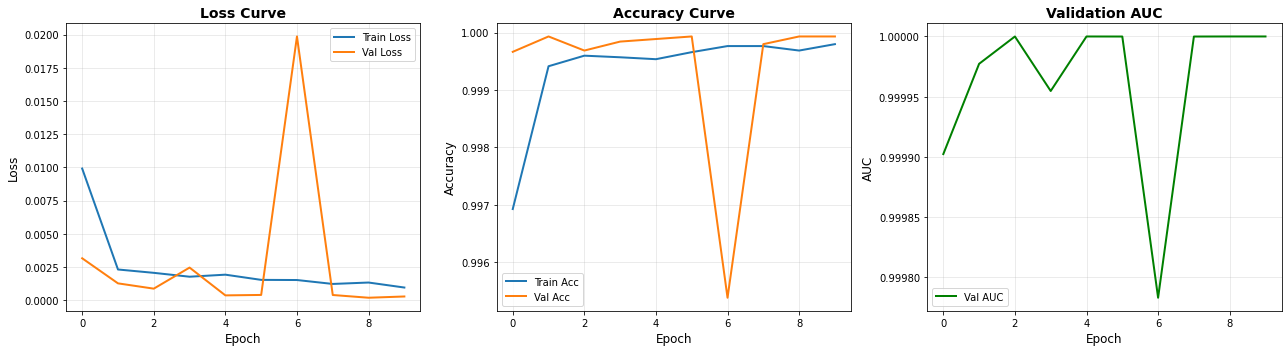


✓ Training curves saved to /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_Grid_8x8_ResNet50/training_curves.png


In [12]:
# ============================================================================
# PLOT TRAINING HISTORY
# ============================================================================

with open(os.path.join(OUTPUT_DIR, 'training_history.json'), 'r') as f:
    history = json.load(f)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss Curve', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy Curve', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUC
axes[2].plot(history['val_auc'], label='Val AUC', linewidth=2, color='green')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('AUC', fontsize=12)
axes[2].set_title('Validation AUC', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Training curves saved to {OUTPUT_DIR}/training_curves.png")


Loading best model for final evaluation...
✓ Best model loaded successfully.


Evaluating: 100%|██████████| 2803/2803 [05:37<00:00,  8.32it/s]



FINAL TEST SET RESULTS
Test Accuracy:  0.9999
Test AUC:       1.0000
Best Threshold: 0.3457

Classification Report:
              precision    recall  f1-score   support

       Clean     1.0000    1.0000    1.0000     22424
       Noisy     1.0000    1.0000    1.0000     22424

    accuracy                         1.0000     44848
   macro avg     1.0000    1.0000    1.0000     44848
weighted avg     1.0000    1.0000    1.0000     44848

Confusion Matrix:
[[22424     0]
 [    1 22423]]



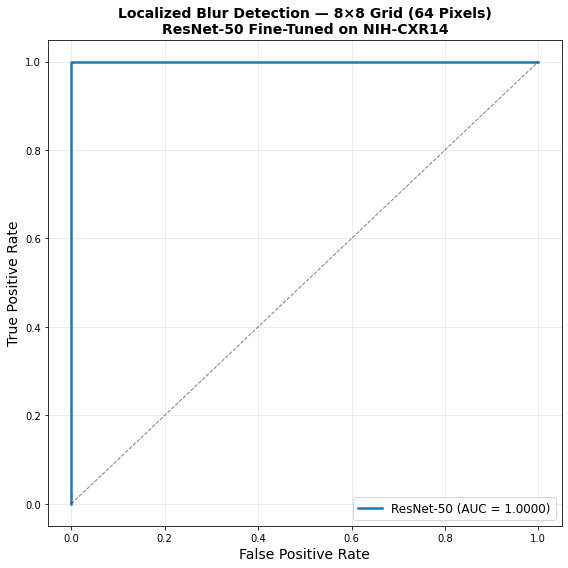

✓ ROC curve saved to /home/jupyter-yin10/Image_Analysis/NIH_Localized_Blur_Grid_8x8_ResNet50/final_roc_curve.png


In [14]:
# ============================================================================
# FINAL EVALUATION ON TEST SET
# ============================================================================

import torch
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    roc_curve,
    auc as sklearn_auc,
    confusion_matrix
)

print("\nLoading best model for final evaluation...")

# --------------------------------------------------------------------------
# Load Best Model
# --------------------------------------------------------------------------
best_model = create_resnet50_model().to(device)

checkpoint = torch.load(
    os.path.join(OUTPUT_DIR, "best_model.pth"), 
    map_location=device, 
    weights_only=False  # <--- ADD THIS
)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

print("✓ Best model loaded successfully.")

# --------------------------------------------------------------------------
# Evaluate on Test Set
# --------------------------------------------------------------------------
_, test_acc, test_probs, test_labels = evaluate(
    best_model, test_loader, criterion, device
)

test_probs = np.array(test_probs)
test_labels = np.array(test_labels)

# --------------------------------------------------------------------------
# ROC Curve + AUC
# --------------------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
test_auc = sklearn_auc(fpr, tpr)

# --------------------------------------------------------------------------
# Find Best Threshold (Youden Index)
# --------------------------------------------------------------------------
best_thresh_idx = np.argmax(tpr - fpr)
best_thresh = thresholds[best_thresh_idx]

test_preds = (test_probs >= best_thresh).astype(int)

# --------------------------------------------------------------------------
# Print Results
# --------------------------------------------------------------------------
print(f"\n{'='*70}")
print("FINAL TEST SET RESULTS")
print(f"{'='*70}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Best Threshold: {best_thresh:.4f}")

print(f"\nClassification Report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=['Clean', 'Noisy'],
    digits=4
))

print("Confusion Matrix:")
print(confusion_matrix(test_labels, test_preds))

print(f"{'='*70}\n")

# --------------------------------------------------------------------------
# Plot ROC Curve
# --------------------------------------------------------------------------
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, linewidth=2.5,
         label=f'ResNet-50 (AUC = {test_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)

plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)

plt.title(
    f'Localized Blur Detection — 8×8 Grid (64 Pixels)\n'
    f'ResNet-50 Fine-Tuned on NIH-CXR14',
    fontsize=14,
    fontweight='bold'
)

plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "final_roc_curve.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ ROC curve saved to {OUTPUT_DIR}/final_roc_curve.png")